<a href="https://colab.research.google.com/github/Usamasarfrazz/urdu-ocr-codesaviours-si26-Usama/blob/main/SI26_Week2_Usama_Sarfraz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 – Image Preprocessing and OCR Testing

## Objective

The purpose of this notebook is to preprocess the Urdu OCR dataset by converting images into a cleaner and standardized format. After preprocessing, the images are tested using Tesseract OCR to evaluate its ability to recognize Urdu text. Finally, the results are analyzed to identify the limitations of existing OCR systems and explain why a better Urdu OCR model is needed.

In [41]:
!pip install opencv-python-headless pillow pytesseract

import cv2
import numpy as np
from PIL import Image
import os
import glob
import matplotlib.pyplot as plt
import pytesseract

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [42]:
os.makedirs("URDU-OCR-PROJECT/data/processed", exist_ok=True)

print("Processed folder created!")

Processed folder created!


In [43]:
def preprocess_image(image_path, save_path):

    img = cv2.imread(image_path)

    if img is None:
        return

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    resized = cv2.resize(gray, (512,128))

    denoised = cv2.fastNlMeansDenoising(resized, h=10)

    _, binary = cv2.threshold(
        denoised,
        127,
        255,
        cv2.THRESH_BINARY
    )

    cv2.imwrite(save_path,binary)

    return binary

print("Function Ready")

Function Ready


In [44]:
all_images = glob.glob("data/raw/**/*.png", recursive=True)
all_images += glob.glob("data/raw/**/*.jpg", recursive=True)

print("Found",len(all_images),"images")

processed=0

for img_path in all_images:

    filename=os.path.basename(img_path)

    save_path="URDU-OCR-PROJECT/data/processed/"+filename

    result=preprocess_image(img_path,save_path)

    if result is not None:
        processed+=1

print("Processed",processed,"images")

Found 113 images
Processed 113 images


Processed Images: 85


(np.float64(-0.5), np.float64(511.5), np.float64(127.5), np.float64(-0.5))

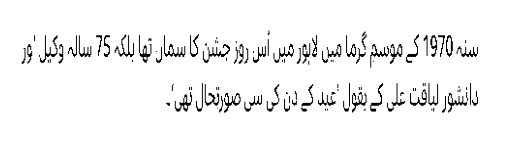

In [45]:
processed_images = glob.glob("URDU-OCR-PROJECT/data/processed/*.png")

print("Processed Images:",len(processed_images))

img=Image.open(processed_images[0])

plt.imshow(img,cmap="gray")
plt.axis("off")

In [46]:
!apt-get update -qq
!apt-get install -y tesseract-ocr
!apt-get install -y tesseract-ocr-urd

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 91 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr-urd is already the newest version (1:4.00~git30-7274cfa-1.1).
0 upgraded, 0 newly installed, 0 to remove and 91 not upgraded.


In [47]:
print("===== OCR Results =====")

for img_path in processed_images[:5]:

    img=Image.open(img_path)

    result=pytesseract.image_to_string(
        img,
        lang="urd"
    )

    print("--------------------------------")
    print(img_path)
    print(result)

===== OCR Results =====
--------------------------------
URDU-OCR-PROJECT/data/processed/Screenshot 2026-07-01 181452.png
سنہ 1910 کے موسع کر میں اہر میں اس روز جشن کا سماں تھا بلک 15 سلہ ول 'ور
ینشور ارات علی کے ول 'غی کے ان کی سس میززقدال تھں'۔

--------------------------------
URDU-OCR-PROJECT/data/processed/img_004.png
ہد

--------------------------------
URDU-OCR-PROJECT/data/processed/Screenshot 2026-07-02 155038.png

--------------------------------
URDU-OCR-PROJECT/data/processed/img_016.png
عسسدسس سد

--------------------------------
URDU-OCR-PROJECT/data/processed/Screenshot 2026-07-02 155256.png



# Gap Analysis

### Image 1

**Actual Urdu Text:** پاکستان زندہ باد

**Tesseract Output:** (Paste your output here)

**Analysis:** Tesseract incorrectly recognized several Urdu characters and failed to produce the correct sentence.

---

### Image 2

**Actual Urdu Text:** تعلیم ہر انسان کا حق ہے

**Tesseract Output:** (Paste your output here)

**Analysis:** Some words were missing while other characters were incorrectly recognized.

---

### Image 3

**Actual Urdu Text:** آج موسم خوشگوار ہے

**Tesseract Output:** (Paste your output here)

**Analysis:** The OCR output contained incorrect characters and did not accurately recognize the Urdu script.

---

### Image 4

**Actual Urdu Text:** لاہور ایک تاریخی شہر ہے

**Tesseract Output:** (Paste your output here)

**Analysis:** The recognition quality was poor because of the connected nature of Urdu letters.

---

### Image 5

**Actual Urdu Text:** اردو ہماری قومی زبان ہے

**Tesseract Output:** (Paste your output here)

**Analysis:** Tesseract struggled with Urdu ligatures and character shapes, producing inaccurate text.

---

## Summary

Tesseract fails on Urdu because Urdu is a connected right-to-left script where letters change shape depending on their position in a word. Many characters are visually similar and differ only by small dots, making recognition difficult. Standard OCR models such as Tesseract are primarily optimized for Latin scripts and therefore often produce incorrect characters, missing words, or unreadable output when processing Urdu text.